In [1]:
import numpy as np
np.random.seed(42)

In [2]:
from pathlib import Path
figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

In [3]:
import pandas as pd

merged_df = pd.read_csv("../data/processed/MD_merged_crime_college.csv")
merged_df.head()

,county_clean,crime_total,crime_rate,population,Annual Number of Public High School Graduates,2-Year College Enrollment,enroll_4yr,college_enrollment_total
0,allegany county,231.804348,309.823913,75763.413043,642,2586.0,4831.0,7417.0
1,anne arundel county,2185.021739,462.930435,466645.108696,5268,12655.0,548.0,13203.0
2,baltimore city,14311.978261,2021.226087,703032.391304,4108,4909.0,59254.0,64163.0
3,baltimore county,5659.152174,774.989130,738704.956522,7171,17732.0,42571.0,60303.0
4,calvert county,187.608696,311.117391,64829.152174,1227,NaN,NaN,0.0


In [4]:
print("Shape:", merged_df.shape)
print("Counties:", merged_df["county_clean"].nunique())
merged_df.describe()

#check for missing values
merged_df.isna().sum()

Shape: (24, 8)
Counties: 24


county_clean                                      0
crime_total                                       0
crime_rate                                        0
population                                        0
Annual Number of Public High School Graduates     0
2-Year College Enrollment                         8
enroll_4yr                                       11
college_enrollment_total                          0
dtype: int64

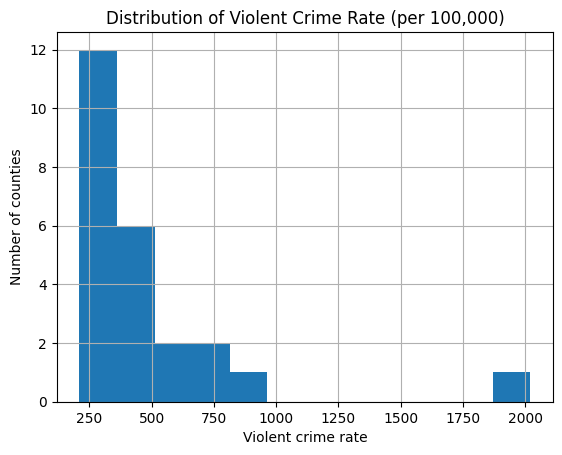

In [5]:
#check for skewness, outliers, weird ranges
#crime rate distribution

import matplotlib.pyplot as plt

plt.figure()
merged_df["crime_rate"].hist(bins=12)
plt.title("Distribution of Violent Crime Rate (per 100,000)")
plt.xlabel("Violent crime rate")
plt.ylabel("Number of counties")
plt.show()

plt.tight_layout()
plt.savefig(figures_dir / "crime_rate_distribution.png", dpi=200)
plt.close()

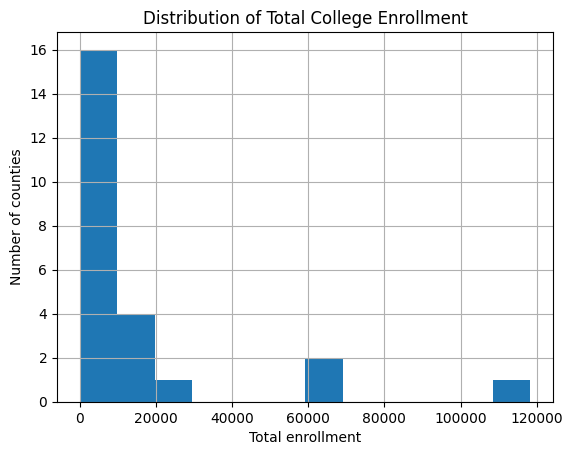

In [6]:
#check for skewness, outliers, weird ranges
#college enrollment distribution

plt.figure()
merged_df["college_enrollment_total"].hist(bins=12)
plt.title("Distribution of Total College Enrollment")
plt.xlabel("Total enrollment")
plt.ylabel("Number of counties")
plt.show()

plt.tight_layout()
plt.savefig(figures_dir / "enrollment_distribution.png", dpi=200)
plt.close()

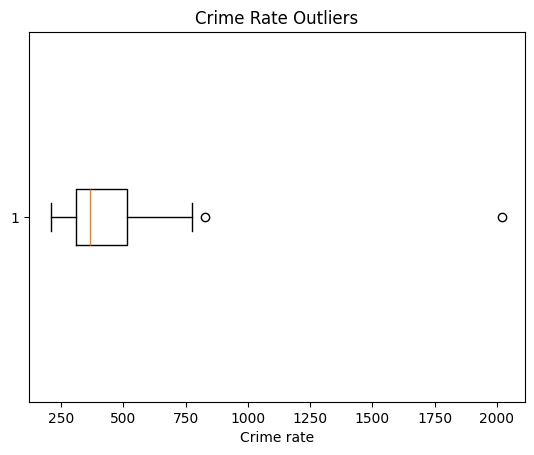

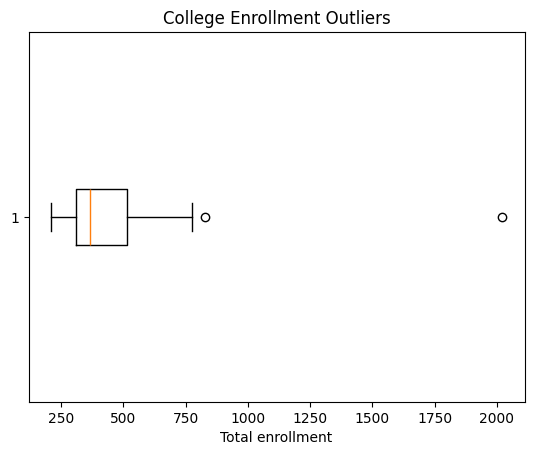

In [7]:
#outlier check
#boxplots

#crime rate
plt.figure()
plt.boxplot(merged_df["crime_rate"].dropna(), vert=False)
plt.title("Crime Rate Outliers")
plt.xlabel("Crime rate")
plt.show()

plt.tight_layout()
plt.savefig(figures_dir / "crime_rate_outliers.png", dpi=200)
plt.close()

#college enrollment
plt.figure()
plt.boxplot(merged_df["crime_rate"].dropna(), vert=False)
plt.title("College Enrollment Outliers")
plt.xlabel("Total enrollment")
plt.show()

plt.tight_layout()
plt.savefig(figures_dir / "enrollment_outliers.png", dpi=200)
plt.close()

In [8]:
#create enrollment rate
merged_df["enrollment_per_1000"] = (
    merged_df["college_enrollment_total"] / merged_df["population"] * 1000
)

In [9]:
#Using bivariate analysis, we'll answer the research question of "Does neighborhood violence relate to college enrollment?"
#scatterplot: crime rate vs college enrollment

plt.figure()
plt.scatter(
    merged_df["crime_rate"],
    merged_df["enrollment_per_1000"],
    alpha=0.6
)

plt.title("Crime Rate vs College Enrollment per 1,000 Residents (MD Counties)")
plt.xlabel("Crime rate (per 100,000 people)")
plt.ylabel("College enrollment per 1,000 residents")

plt.tight_layout()
plt.savefig(figures_dir / "crime_vs_enrollment_scatter.png", dpi=200)
plt.close()

Interpretation: Does it look negative, positive, or no relationship?

Are a few counties dominating (big enrollment)?

In [10]:
#Correlation analysis
corr_cols = [
    "crime_rate",
    "crime_total",
    "college_enrollment_total",
    "enrollment_per_1000",
    "population"
]

pearson_corr = merged_df[corr_cols].corr(method = "pearson")
spearman_corr = merged_df[corr_cols].corr(method = "spearman")

pearson_corr, spearman_corr

(                          crime_rate  crime_total  college_enrollment_total  \
 crime_rate                  1.000000     0.914420                  0.604268   
 crime_total                 0.914420     1.000000                  0.777377   
 college_enrollment_total    0.604268     0.777377                  1.000000   
 enrollment_per_1000         0.373353     0.401446                  0.596174   
 population                  0.503902     0.750779                  0.827299   
 
                           enrollment_per_1000  population  
 crime_rate                           0.373353    0.503902  
 crime_total                          0.401446    0.750779  
 college_enrollment_total             0.596174    0.827299  
 enrollment_per_1000                  1.000000    0.347903  
 population                           0.347903    1.000000  ,
                           crime_rate  crime_total  college_enrollment_total  \
 crime_rate                  1.000000     0.447826                  0.2

Interpretation: Pearson near 0 → weak linear relationship

Negative → higher crime → lower enrollment

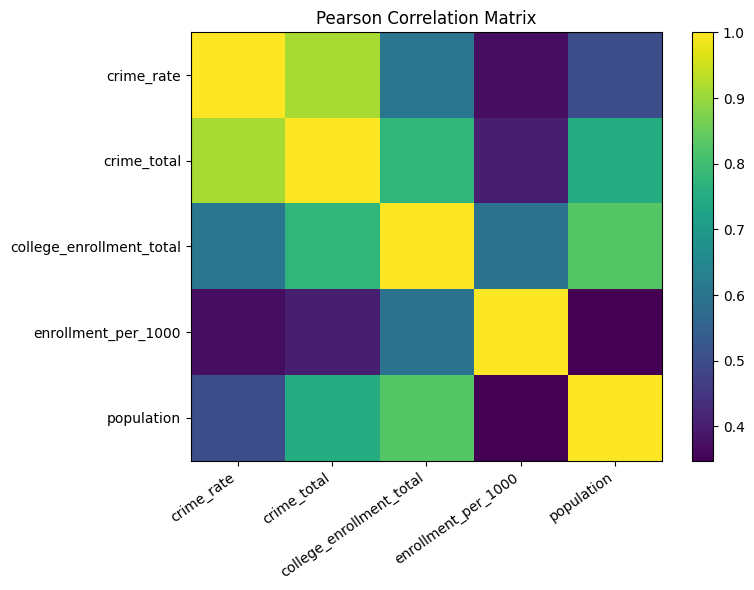

In [11]:
#Correlation heatmap
plt.figure(figsize=(8,6))
plt.imshow(pearson_corr, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=35, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Pearson Correlation Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

Distributional properties.
Crime rates are right-skewed with several high-violence outliers, while college enrollment totals show strong positive skew due to population differences across counties.

Bivariate relationship.
The scatterplot indicates a weak to moderate negative association between violent crime rate and college enrollment per capita, with substantial dispersion, suggesting potential confounding by population size and regional socioeconomic factors.

Correlation structure.
Pearson and Spearman correlations are consistent in direction but differ slightly in magnitude, indicating mild nonlinearity and the influence of extreme values.